# Mean-based signature scoring

**zscore 方法基因签名评分**

Score the public IMvigor210 demonstration matrix (872 features × 348 samples). This is a restricted feature panel, not a complete transcriptome; only signatures with sufficient overlap are returned.

This notebook uses public [IOBR release fixtures](https://github.com/IOBR/IOBR/releases/tag/data-v1.0). Source URLs and checksums are in [data/manifest.json](data/manifest.json). Figures are descriptive; no clinical outcome labels are supplied.

**Setup:** from the repository root, install with `python -m pip install ".[tutorials]"`. Restart the notebook kernel after installation.

In [1]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import iobrx

# Works from the repository root or from the tutorials directory.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tutorials" / "_common.py").exists())
sys.path.insert(0, str(ROOT / "tutorials"))
from _common import (configure, load, tpm_input, runtime_info, numeric_scores,
                     short_samples, clean_labels, panel, heatmap, scatter,
                     stacked, composition_figure, fractions, save_figure, save_result, COLORS, TEAL, RUST, NAVY)
configure(2)
iobrx.set_threads(8)
display(runtime_info())


{'iobrx': '0.2.0',
 'threads': 8,
 'native_available': True,
 'native_reason': None,
 'sorting': 'numpy CPU dispatch',
 'requires_avx512': False,
 'bundled_openblas_found': True,
 'versions': {'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scipy': '1.16.3',
  'scikit-learn': '1.7.2',
  'iobrpy': '0.2.1',
  'gseapy': '1.3.1',
  'matplotlib': '3.10.9'}}

## 1. Inspect the input / 检查输入

Expression matrices are **genes × samples**. The analysis uses every sample; any figure subset is stated explicitly.

In [2]:
expression = load("imvigor210_eset")
input_shape = expression.shape
display(expression.iloc[:5, :4])


,SAMf2ce197162ce,SAM698d8d76b934,SAMc1b27bc16435,SAM85e41e7f33f9
rownames,,,,
LOC100093631,3.100940,2.820764,3.705899,2.810128
LOC100126784,-2.623775,-4.256052,-5.410445,-2.076004
LOC100128108,-1.501784,0.520052,-0.766588,-2.076004
LOC100128288,-0.336198,-1.220428,-1.951013,-1.258868
LOC100128361,0.254547,0.292385,-0.200991,-0.025377


## 2. Run the analysis / 运行分析

The timer covers the call below, including its resource setup. Data loading above and plotting below are excluded. This is a single run; repeated benchmark medians are reported separately in the README.

In [3]:
started = perf_counter()
result = iobrx.calculate_sig_score(expression, "signature_collection", method="zscore", mini_gene_count=3, adjust_eset=True, n_threads=8)
elapsed = perf_counter() - started
display(save_result(result, "04_signature_zscore", elapsed, input_shape))

Completed in 0.547 s; input 872 features × 348 samples.


,analysis,seconds,input_shape,output_shapes,threads
0,04_signature_zscore,0.547112,"[872, 348]","{'result': [348, 60]}",8


In [4]:
display(result.head() if isinstance(result, pd.DataFrame) else {key: value.shape if isinstance(value, pd.DataFrame) else list(value) for key, value in result.items()})

,ID,CD_8_T_effector,DDR,APM,Immune_Checkpoint,CellCycle_Reg,Pan_F_TBRs,Histones,EMT1,EMT2,...,CD4_c1_Treg,CD4_c3_Tfh,CD4_c4_Tstr,CD4_c5_CTL,CD4_c7_Tn_TCEA3,CD8_c1_Tex,CD8_c2_Teff,CD8_c4_Tstr,Mph_04_TREM2,TMEscore_CIR
0,SAMf2ce197162ce,0.095159,4.842349,7.959208,0.814891,6.076190,6.588683,6.154833,5.635649,5.282650,...,1.729897,-0.629757,0.824214,1.353359,5.818486,-0.137593,2.504015,0.824214,4.011564,-2.212295
1,SAM698d8d76b934,1.351849,5.149831,8.927719,1.325271,5.566909,5.459791,6.769310,5.194775,3.849971,...,1.319857,0.301984,2.901202,1.380900,5.944430,0.957764,1.920573,2.901202,5.235842,1.207098
2,SAMc1b27bc16435,2.123191,4.966561,8.001440,1.134271,5.633615,5.505373,6.988202,4.905357,3.228082,...,2.572221,0.224328,2.159330,2.719733,5.531510,1.217809,3.319064,2.159330,4.196960,0.484562
3,SAM85e41e7f33f9,2.987797,4.862935,9.199026,2.177699,5.760003,6.344835,6.918678,5.293817,5.291403,...,2.577785,1.231484,3.552586,4.005484,6.209183,2.203781,3.852939,3.552586,6.161193,0.653540
4,SAMf275eb859a39,1.492734,4.793889,9.080575,0.951151,5.583201,4.810659,4.887634,4.084315,2.677116,...,2.101755,-0.598498,2.276132,2.296727,5.901045,0.552871,2.590806,2.276132,4.413491,0.382668


## 3. Visualize and export / 作图与导出

White background, restrained colors, thin axes and editable vector text. Heatmap z-scores are display-only; exported result tables keep the original values. `S01`, `S02`, … follow the sample order of each displayed matrix; the mapping is printed below.

For the IMvigor210 heatmaps, only the first 30 samples are shown (24 per panel in the integration notebook); scoring and distributions use all 348.

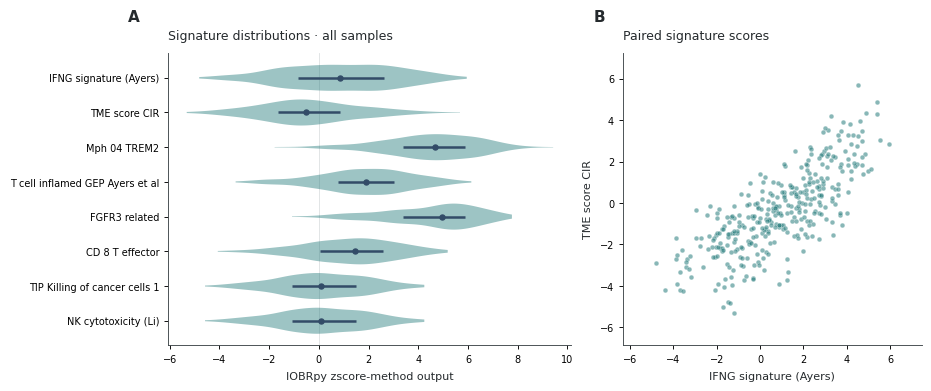

In [5]:
scores = numeric_scores(result).astype(float)
features = scores.std().nlargest(8).index
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), gridspec_kw={"width_ratios": [1.35, 1]}, layout="constrained")
vectors = [scores[name].dropna().to_numpy() for name in features[::-1]]
parts = axes[0].violinplot(vectors, vert=False, showextrema=False, widths=0.75)
for body in parts["bodies"]:
    body.set_facecolor(TEAL); body.set_edgecolor("none"); body.set_alpha(0.45)
axes[0].scatter([np.median(v) for v in vectors], np.arange(1, len(vectors)+1), s=13, color=NAVY, zorder=3)
quartiles = np.array([np.percentile(v, [25, 75]) for v in vectors])
axes[0].hlines(np.arange(1, len(vectors)+1), quartiles[:, 0], quartiles[:, 1], color=NAVY, linewidth=1.8)
axes[0].axvline(0, color="#DDE1E2", linewidth=0.6, zorder=0)
axes[0].set_yticks(np.arange(1, len(vectors)+1), clean_labels(features[::-1]))
axes[0].set(xlabel="IOBRpy zscore-method output", ylim=(0.3, 8.7))
x, y = features[:2]
scatter(axes[1], scores[x], scores[y], *clean_labels([x, y]))
panel(axes[0], "A", "Signature distributions · all samples")
panel(axes[1], "B", "Paired signature scores")
save_figure(fig, '04_signature_zscore')


In [6]:
sample_ids = expression.columns if "expression" in globals() else counts.columns if "counts" in globals() else tpm.columns
display(pd.DataFrame({"plot_label": short_samples(sample_ids), "original_sample_id": sample_ids}).head(30))

,plot_label,original_sample_id
0,S01,SAMf2ce197162ce
1,S02,SAM698d8d76b934
2,S03,SAMc1b27bc16435
3,S04,SAM85e41e7f33f9
4,S05,SAMf275eb859a39
5,S06,SAM7f0d9cc7f001
6,S07,SAM4305ab968b90
7,S08,SAMcf018fee2acd
8,S09,SAMb2f1d0e54ece
9,S10,SAMcc4675f394a1


## 4. Interpretation and limits / 解读与边界

The upstream method named 'zscore' averages the preprocessed expression of each signature. It does not guarantee that each returned signature has mean zero and variance one. Do not confuse its name with the within-feature z-scores used only for heatmap display.

**Reusing this tutorial:** replace the input-loading cell with your own `pd.read_csv(..., index_col=0)`; keep the matrix orientation, identifier type and expression scale consistent with this example. Check gene overlap before interpreting estimates.

Figures are written to `tutorials/figures/04_signature_zscore.png`, `.pdf`, and `.svg`. Compact output tables and timing metadata are written to `tutorials/results/`. Large count/TPM matrices remain in `result`; save them explicitly with `result.to_parquet(...)` if needed.